In [2]:
import pandas as pd
import numpy as np

# Create a dirty dataset
dirty_data = {
    'Employee_ID': [101, 102, 102, 103, 104],                 # 102 is a duplicate row!
    'Name': ['Alice', 'Bob', 'Bob', 'Charlie', 'David'],
    'Age': [25, 31, 31, np.nan, 45],                           # Charlie's age is missing (NaN)
    'Salary': ['$50,000', '$60,000', '$60,000', '$70,000', '$120,000'] # Strings with symbols instead of numbers
}

df = pd.DataFrame(dirty_data)
print("--- Raw Dirty Data ---")
print(df)
print("\n--- Data Types ---")
print(df.dtypes)

--- Raw Dirty Data ---
   Employee_ID     Name   Age    Salary
0          101    Alice  25.0   $50,000
1          102      Bob  31.0   $60,000
2          102      Bob  31.0   $60,000
3          103  Charlie   NaN   $70,000
4          104    David  45.0  $120,000

--- Data Types ---
Employee_ID      int64
Name               str
Age            float64
Salary             str
dtype: object


In [3]:
df=df.drop_duplicates()  # Remove duplicate rows
print("\n--- After Removing Duplicates ---")
print(df)


--- After Removing Duplicates ---
   Employee_ID     Name   Age    Salary
0          101    Alice  25.0   $50,000
1          102      Bob  31.0   $60,000
3          103  Charlie   NaN   $70,000
4          104    David  45.0  $120,000


In [4]:
df['Salary'] = df['Salary'].str.replace('$', '').str.replace(',', '').astype(float)
print("\n--- After Cleaning Salary Column ---")
print(df)


--- After Cleaning Salary Column ---
   Employee_ID     Name   Age    Salary
0          101    Alice  25.0   50000.0
1          102      Bob  31.0   60000.0
3          103  Charlie   NaN   70000.0
4          104    David  45.0  120000.0


In [5]:
median_age=df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print("\n--- After Imputing Missing Age ---")
print(df)
print("\n--- Final Data Types ---")
print(df.dtypes)


--- After Imputing Missing Age ---
   Employee_ID     Name   Age    Salary
0          101    Alice  25.0   50000.0
1          102      Bob  31.0   60000.0
3          103  Charlie  31.0   70000.0
4          104    David  45.0  120000.0

--- Final Data Types ---
Employee_ID      int64
Name               str
Age            float64
Salary         float64
dtype: object


In [6]:
print("\n--adding new column--")
df['Bonus'] = df['Salary'] * 0.1
print(df)


--adding new column--
   Employee_ID     Name   Age    Salary    Bonus
0          101    Alice  25.0   50000.0   5000.0
1          102      Bob  31.0   60000.0   6000.0
3          103  Charlie  31.0   70000.0   7000.0
4          104    David  45.0  120000.0  12000.0


In [8]:
print("\n---filtering employees with age>30---")
filtered_df = df[df['Age'] >30]
print(filtered_df)


---filtering employees with age>30---
   Employee_ID     Name   Age    Salary    Bonus
1          102      Bob  31.0   60000.0   6000.0
3          103  Charlie  31.0   70000.0   7000.0
4          104    David  45.0  120000.0  12000.0


In [10]:
# 1. Get a quick statistical snapshot of your numerical columns
print("--- Statistical Summary ---")
print(df.describe())

# 2. Grouping data to compare averages (Let's add a quick Department column to see this in action)
df['Department'] = ['Tech', 'HR', 'Tech', 'HR']

print("\n--- Average Salary by Department ---")
department_summary = df.groupby('Department')['Salary'].mean()
print(department_summary)

print("\n---result df---")
print(df)

--- Statistical Summary ---
       Employee_ID        Age        Salary         Bonus
count     4.000000   4.000000       4.00000      4.000000
mean    102.500000  33.000000   75000.00000   7500.000000
std       1.290994   8.485281   31091.26351   3109.126351
min     101.000000  25.000000   50000.00000   5000.000000
25%     101.750000  29.500000   57500.00000   5750.000000
50%     102.500000  31.000000   65000.00000   6500.000000
75%     103.250000  34.500000   82500.00000   8250.000000
max     104.000000  45.000000  120000.00000  12000.000000

--- Average Salary by Department ---
Department
HR      90000.0
Tech    60000.0
Name: Salary, dtype: float64

---result df---
   Employee_ID     Name   Age    Salary    Bonus Department
0          101    Alice  25.0   50000.0   5000.0       Tech
1          102      Bob  31.0   60000.0   6000.0         HR
3          103  Charlie  31.0   70000.0   7000.0       Tech
4          104    David  45.0  120000.0  12000.0         HR


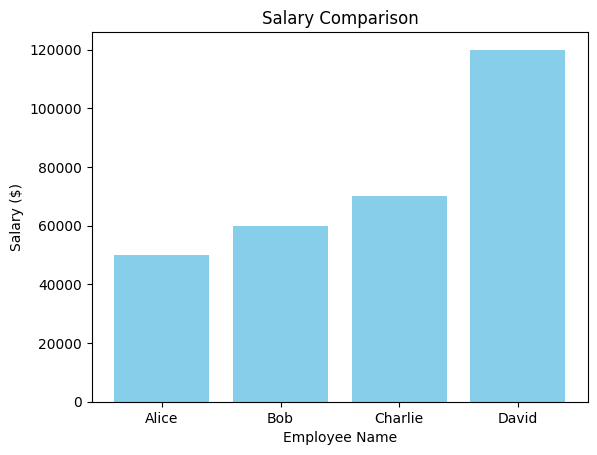

In [11]:
import matplotlib.pyplot as plt

# Create a bar chart of Employee Names vs Salaries
plt.bar(df['Name'], df['Salary'], color='skyblue')

# Add labels and a title
plt.xlabel('Employee Name')
plt.ylabel('Salary ($)')
plt.title('Salary Comparison')

# Display the plot
plt.show()

In [12]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile) of the Salary column
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Determine the upper and lower fences
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Salary Range Fences -> Lower: {lower_bound}, Upper: {upper_bound}")

# 4. Filter the dataframe to keep ONLY rows inside the fences
df_no_outliers = df[(df['Salary'] >= lower_bound) & (df['Salary'] <= upper_bound)]

print("\n--- Data After Removing Outliers ---")
print(df_no_outliers)

Salary Range Fences -> Lower: 20000.0, Upper: 120000.0

--- Data After Removing Outliers ---
   Employee_ID     Name   Age    Salary    Bonus Department
0          101    Alice  25.0   50000.0   5000.0       Tech
1          102      Bob  31.0   60000.0   6000.0         HR
3          103  Charlie  31.0   70000.0   7000.0       Tech
4          104    David  45.0  120000.0  12000.0         HR
